In [17]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

from jax import core
from jax import lax
from jax._src.util import safe_map

from probjax.core.random_variable import rv, rv_p
import matplotlib.pyplot as plt
from probjax.distributions import Normal


def f(theta):
    x = jnp.ones(1)
    xs = []
    for i in range(5):
        x = x + 0.1* (theta*x)
        xs.append(x)
    return xs

jaxpr = jax.make_jaxpr(f)(jnp.ones(1))

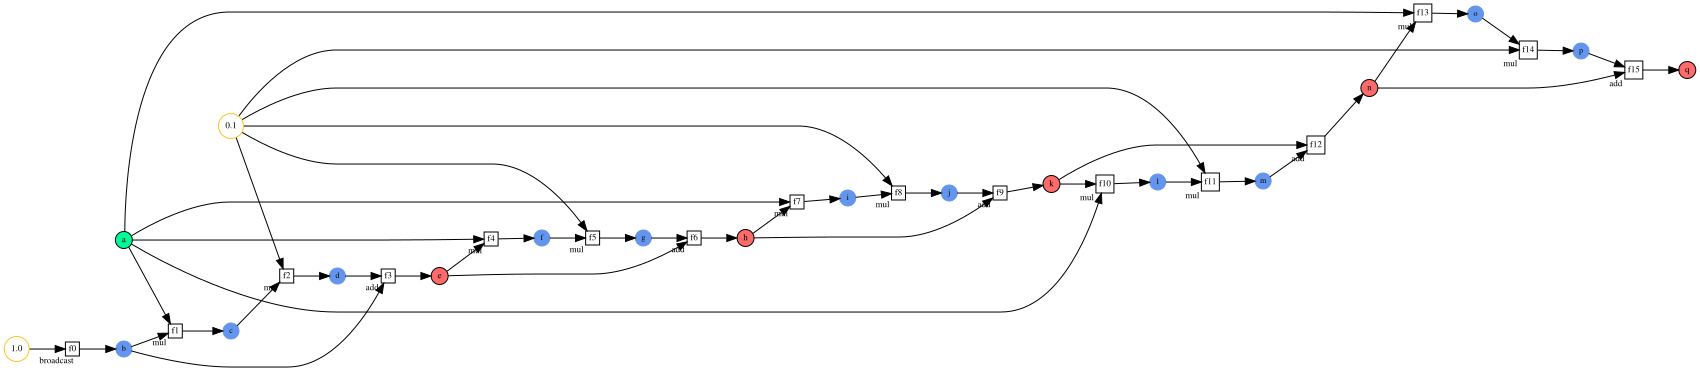

In [19]:

from probjax.core.graph import JaxprGraph
JaxprGraph(jaxpr.jaxpr.invars, jaxpr.jaxpr.constvars, jaxpr.jaxpr.outvars, jaxpr.jaxpr.eqns)

In [2]:
f(theta=jnp.ones(1)*2, dt=0.01)

Array([1.1040808], dtype=float32)

In [3]:
jnp.exp(0.1)

Array(1.105171, dtype=float32, weak_type=True)

In [4]:
def eval_jaxpr(jaxpr, consts, *args):
  # Mapping from variable -> value
  env = {}
  
  def read(var):
    # Literals are values baked into the Jaxpr
    if type(var) is core.Literal:
      return var.val
    return env[var]

  def write(var, val):
    env[var] = val

  # Bind args and consts to environment
  safe_map(write, jaxpr.invars, args)
  safe_map(write, jaxpr.constvars, consts)

  # Loop through equations and evaluate primitives using `bind`
  for eqn in jaxpr.eqns:
    # Read inputs to equation from environment
    
    invals = safe_map(read, eqn.invars)  
    # `bind` is how a primitive is called
    outvals = eqn.primitive.bind(*invals, **eqn.params)
    # Primitives may return multiple outputs or not
    if not eqn.primitive.multiple_results: 
      outvals = [outvals]
    # Write the results of the primitive into the environment
    safe_map(write, eqn.outvars, outvals) 
  # Read the final result of the Jaxpr from the environment
  return safe_map(read, jaxpr.outvars) 

In [5]:
def eval_jaxpr_and_trace(jaxpr, consts, *args):
  # Mapping from variable -> value
  env = {}
  
  def read(var):
    # Literals are values baked into the Jaxpr
    if type(var) is core.Literal:
      return var.val
    return env[var]

  def write(var, val):
    env[var] = val

  # Bind args and consts to environment
  safe_map(write, jaxpr.invars, args)
  safe_map(write, jaxpr.constvars, consts)

  # Loop through equations and evaluate primitives using `bind`
  for eqn in jaxpr.eqns:
    # Read inputs to equation from environment
    
    invals = safe_map(read, eqn.invars)  
    # `bind` is how a primitive is called
    outvals = eqn.primitive.bind(*invals, **eqn.params)
    # Primitives may return multiple outputs or not
    if not eqn.primitive.multiple_results: 
      outvals = [outvals]
    # Write the results of the primitive into the environment
    safe_map(write, eqn.outvars, outvals) 
  # Read the final result of the Jaxpr from the environment
  return safe_map(read, jaxpr.outvars), env

In [4]:
def trace(key, *args):
    return eval_jaxpr_and_trace(jaxpr.jaxpr, jaxpr.consts, key, *args)[-1]

batched_trace = jax.vmap(trace)

In [131]:
x_o = 4.

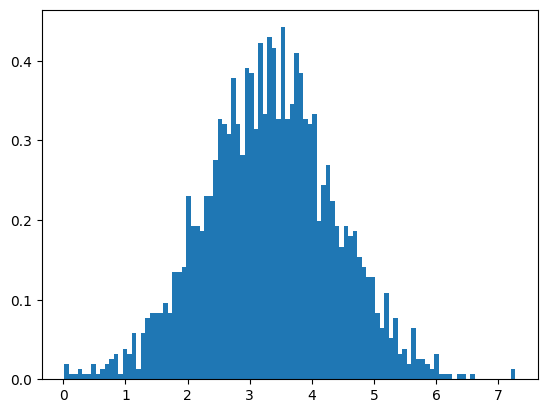

In [132]:
env = batched_trace(jrandom.split(jrandom.PRNGKey(1), 100000), jrandom.normal(jrandom.PRNGKey(2), shape=(100000,)))
noise_dist = list(env.values())[-1]
mask = (noise_dist - x_o)**2 < 0.1
noise_dist = list(env.values())[-3][mask.flatten()]
_ = plt.hist(noise_dist.flatten(), bins=100, density=True)

In [133]:
inverse_registry = {}


def pow_stochastic_inverse(key, eqn):
    exponent = eqn.params["y"]
    if (exponent % 2) == 1:
        return key, lambda x: x**(1/exponent)
    else:
        key1, key2 = jrandom.split(key)
        sign = jrandom.choice(key2, jnp.asarray([-1, 1]))
        return key1, lambda x: sign * x**(1/exponent)
    

def stochastic_add(key, eqn):
    key1, key2 = jrandom.split(key)

    def inverse_add(c):
        #noise = jrandom.normal(key2, shape=c.shape)
        noise = jrandom.choice(key2,noise_dist.flatten(), shape=c.shape)
        out1 = noise
        out2 = c - noise
        return [out1, out2]
    return key1, inverse_add

    

inverse_registry[lax.exp_p] = lambda key,eqn: (key, jnp.log)
inverse_registry[lax.tanh_p] = lambda key, eqn: (key, jnp.arctanh)
inverse_registry[lax.integer_pow_p] = pow_stochastic_inverse
inverse_registry[lax.add_p] = stochastic_add

In [134]:
def inverse_jaxpr(jaxpr, consts, key,*args):
  env = {}
  
  def read(var):
    if type(var) is core.Literal:
      return var.val
    return env[var]

  def write(var, val):
    env[var] = val
  # Args now correspond to Jaxpr outvars
  safe_map(write, jaxpr.outvars, args)
  safe_map(write, jaxpr.constvars, consts)

  # Looping backward
  for eqn in jaxpr.eqns[::-1]:
    if eqn.primitive is rv_p:
      safe_map(write, [eqn.invars[-1]], [key])
      continue
    #  outvars are now invars 
    invals = safe_map(read, eqn.outvars)
    if eqn.primitive not in inverse_registry:
      raise NotImplementedError(
          f"{eqn.primitive} does not have registered inverse.")
    else:
      key, inverse = inverse_registry[eqn.primitive](key, eqn)
      outval = inverse(*invals)
    # Assuming a unary function 
    if not isinstance(outval, list):
      outval = [outval]

    safe_map(write, eqn.invars, outval)
  return safe_map(read, jaxpr.invars), env

In [135]:


out = inverse_jaxpr(jaxpr.jaxpr, jaxpr.consts, jrandom.PRNGKey(0), jnp.asarray([2]))

In [136]:
def inverse_simulator(key, *args):
    return inverse_jaxpr(jaxpr.jaxpr, jaxpr.consts, key, *args)

In [137]:
batched_trace = jax.vmap(trace)
batched_inverse_f = jax.vmap(inverse_simulator)

In [138]:

posterior_samples = batched_inverse_f(jrandom.split(jrandom.PRNGKey(1), 100000), jnp.ones((100000,1))*x_o)

In [139]:
def log_potential(theta,x):
    z = theta**2
    return Normal(z,1.).log_prob(x) + Normal(0.,1.).log_prob(theta)
x = jnp.linspace(-10,10,1000)
unnormalized_posterior =jnp.exp(jax.vmap(log_potential)(x, jnp.ones(1000)*x_o))
posterior = unnormalized_posterior / jnp.trapz(unnormalized_posterior, x)


In [140]:
import matplotlib.pyplot as plt

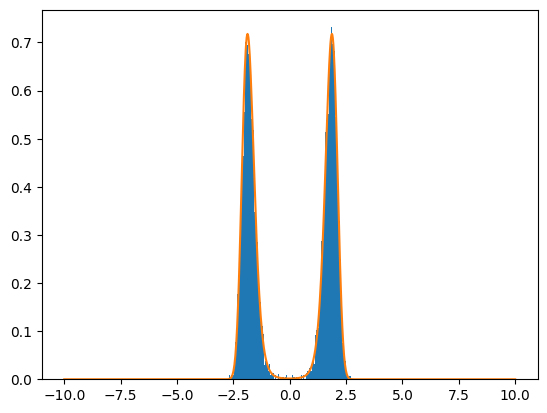

In [141]:
_ = plt.hist(posterior_samples[0][1].flatten(), bins=100, density=True)
plt.plot(x, posterior)

In [150]:
index = -3

list(posterior_samples[1].keys())[index]

e

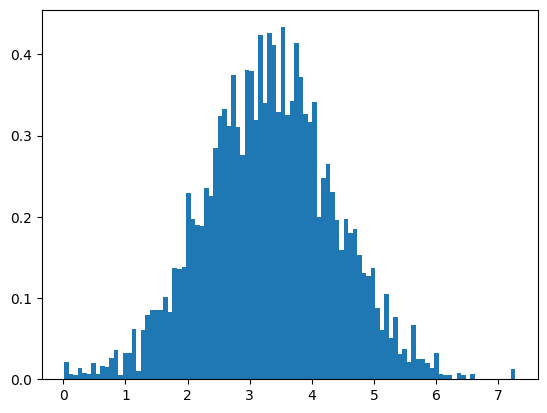

In [151]:
_ = plt.hist(list(posterior_samples[1].values())[index].flatten(), bins=100, density=True)

In [152]:
list(env.keys())[index]

e

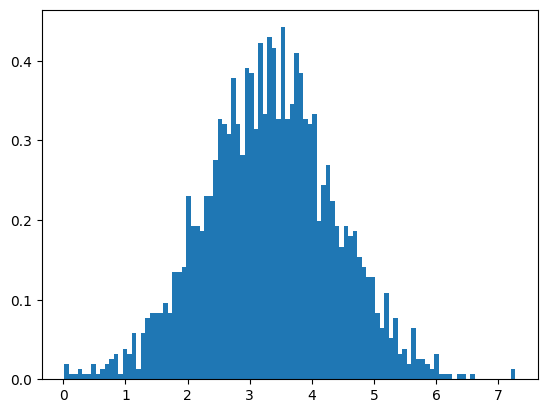

In [153]:
_ = plt.hist(list(env.values())[index][mask.flatten()].flatten(), bins=100, density=True)